# A notebook to explore the L1KD experiment dataset (Nielsen et al. 2025)

General statistics

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns


# 1. Load datasets

# Full L1KD dataset
file_path = "/mnt/storage/ana01/data/13100_2024_339_MOESM1_ESM.xlsx"
sheet_name = "T11_DIA_Interactome_shRNA_vs_sc"
df = pd.read_excel(file_path, sheet_name=sheet_name)


# 2. Explore full L1KD dataset structure

print("Dataset Dimensions:")
print("Rows (number of protein hits):", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn names:", df.columns.tolist())
print("Total number of missing values:", df.isna().sum().sum())

# Summary statistics
print("\nSummary Statistics:")
print(df.describe())

print("\nSignificant hits:")
# 3. Flagging significance (Significance col) and counting significant hits
df["Significant"] = (df["P-value adjusted"] < 0.05) & (df["Log2 Fold-Change"] >= 1)
n_significant = df["Significant"].sum()
n_significant_neg = ((df["P-value adjusted"] < 0.05) & (df["Log2 Fold-Change"] <= -1)).sum()
print(f"Significant proteins in L1KD (p < 0.05 & log2FC ≥ 1): {n_significant}")
print(f"Significantly negatively correlated proteins in L1KD (p < 0.05 & log2FC <= -1): {n_significant_neg}")

Plots for insight into data structure

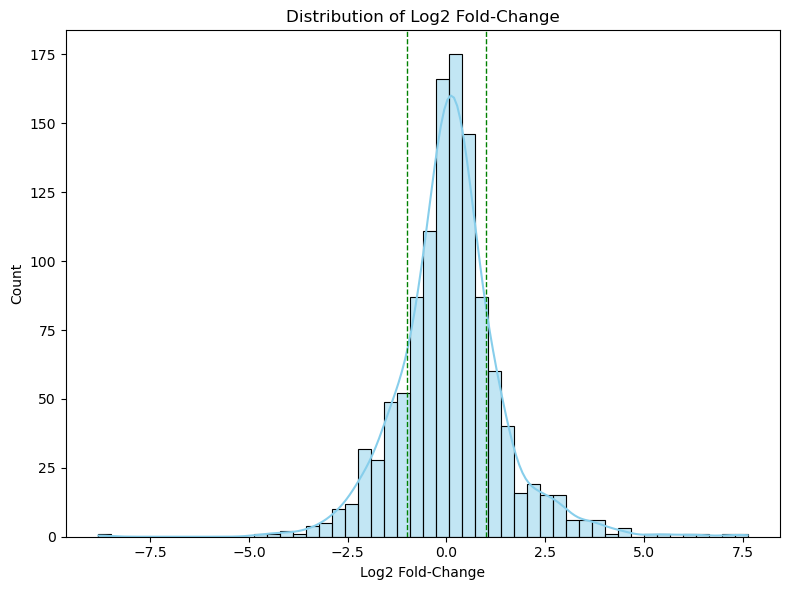

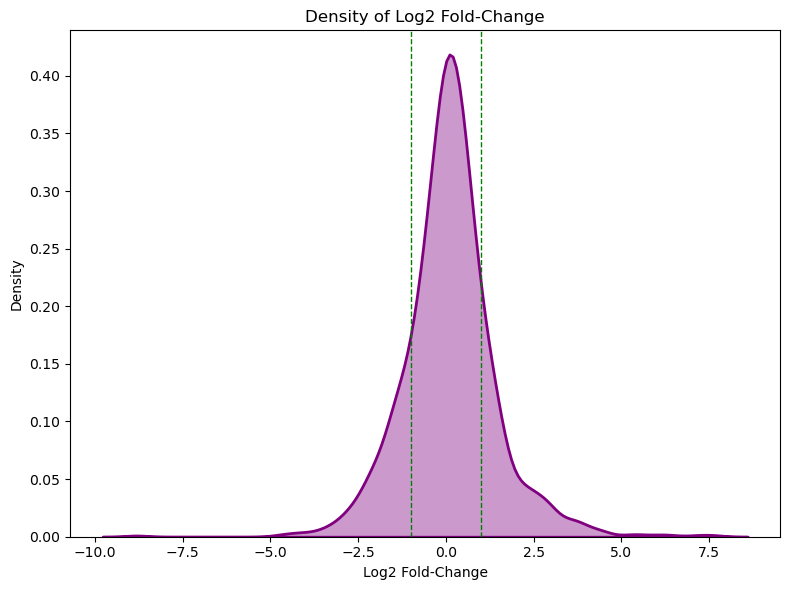

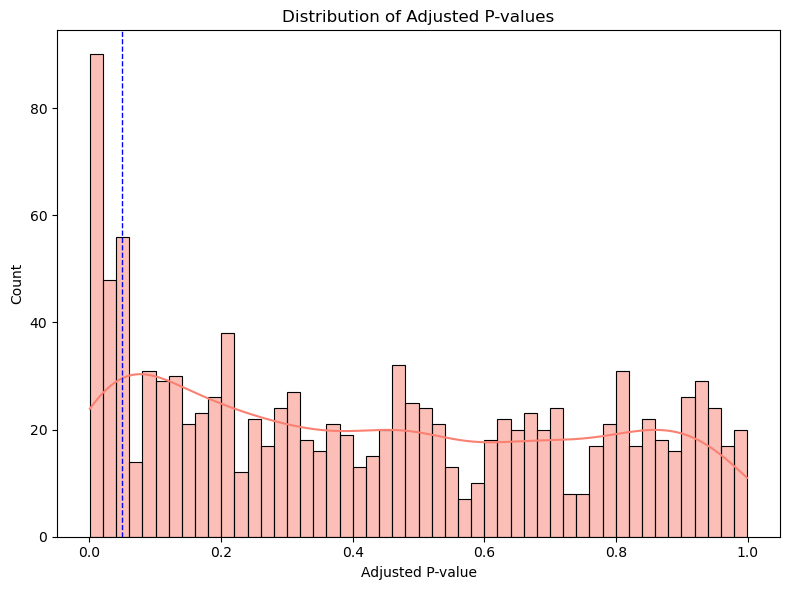

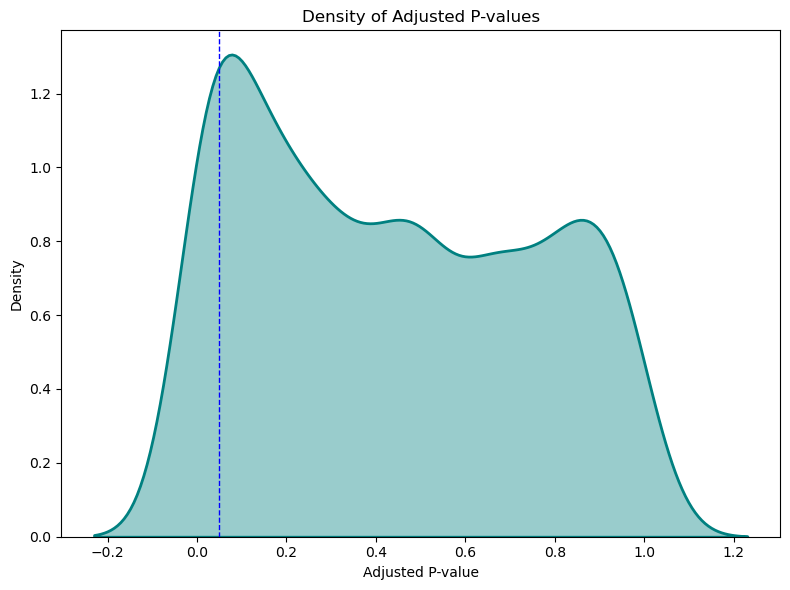

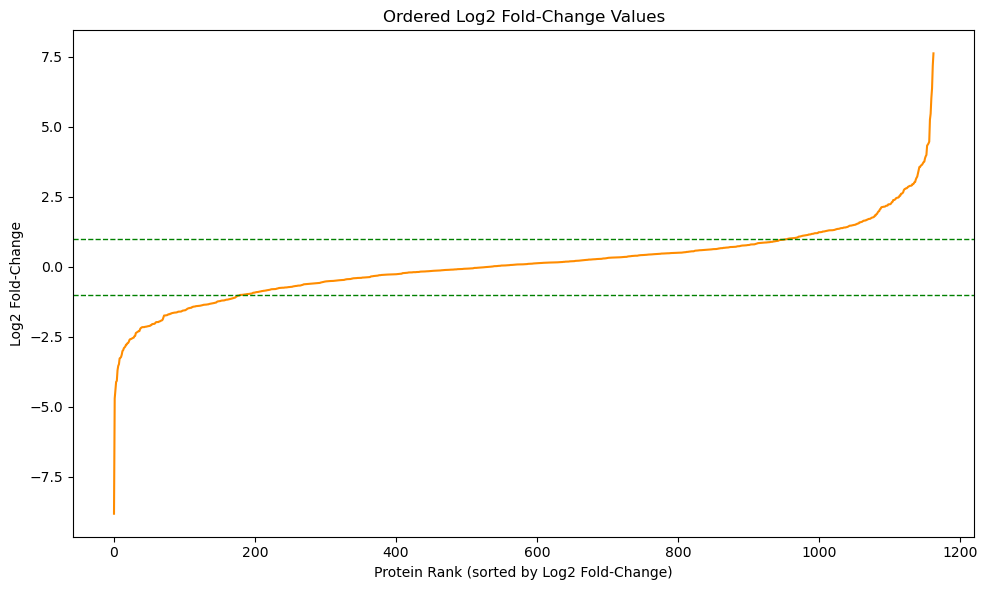

In [3]:
# Distribution of Log2 Fold-Change
plt.figure(figsize=(8, 6))
sns.histplot(df["Log2 Fold-Change"], bins=50, kde=True, color="skyblue")
plt.axvline(1, color='green', linestyle='--', linewidth=1)
plt.axvline(-1, color='green', linestyle='--', linewidth=1)
plt.title("Distribution of Log2 Fold-Change")
plt.xlabel("Log2 Fold-Change")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("/mnt/storage/ana01/results/dataset_exploration/log2fc_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 6))
sns.kdeplot(df["Log2 Fold-Change"], fill=True, color="purple", alpha=0.4, linewidth=2)
plt.axvline(1, color='green', linestyle='--', linewidth=1)
plt.axvline(-1, color='green', linestyle='--', linewidth=1)
plt.title("Density of Log2 Fold-Change")
plt.xlabel("Log2 Fold-Change")
plt.ylabel("Density")
plt.tight_layout()
plt.savefig("/mnt/storage/ana01/results/dataset_exploration/log2fc_density.png", dpi=300, bbox_inches="tight")
plt.show()

# Distribution of Adjusted P-values
plt.figure(figsize=(8, 6))
sns.histplot(df["P-value adjusted"], bins=50,  kde=True, color="salmon")
plt.axvline(0.05, color='blue', linestyle='--', linewidth=1)
plt.title("Distribution of Adjusted P-values")
plt.xlabel("Adjusted P-value")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("/mnt/storage/ana01/results/dataset_exploration/padj_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 6))
sns.kdeplot(df["P-value adjusted"], fill=True, color="teal", alpha=0.4, linewidth=2)
plt.axvline(0.05, color='blue', linestyle='--', linewidth=1)
plt.title("Density of Adjusted P-values")
plt.xlabel("Adjusted P-value")
plt.ylabel("Density")
plt.tight_layout()
plt.savefig("/mnt/storage/ana01/results/dataset_exploration/padj_density.png", dpi=300, bbox_inches="tight")
plt.show()


# Ordered Log2 Fold-Change 
df_sorted = df.sort_values("Log2 Fold-Change").reset_index(drop=True)
plt.figure(figsize=(10, 6))
plt.plot(range(len(df_sorted)), df_sorted["Log2 Fold-Change"], color="darkorange", linewidth=1.5)
plt.axhline(1, color='green', linestyle='--', linewidth=1)
plt.axhline(-1, color='green', linestyle='--', linewidth=1)
plt.title("Ordered Log2 Fold-Change Values")
plt.xlabel("Protein Rank (sorted by Log2 Fold-Change)")
plt.ylabel("Log2 Fold-Change")
plt.tight_layout()
plt.savefig("/mnt/storage/ana01/results/dataset_exploration/log2fc_ordered.png", dpi=300, bbox_inches="tight")
plt.show()


Volcano plot, marking L1KD correlated (+) and anti-correlated (-) groups (Figure A4).

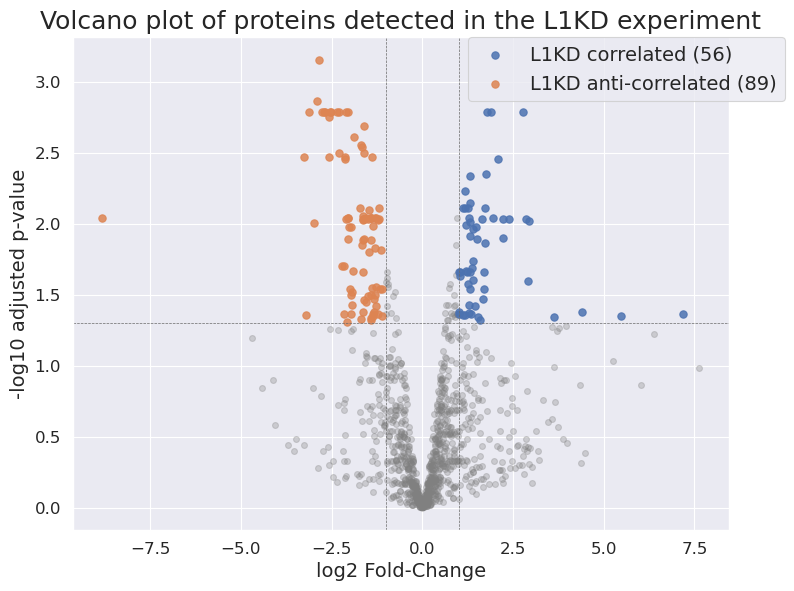

In [4]:
import seaborn as sns

sns.set_theme(style="darkgrid", context="paper")

# Adding the -log10(padj) column for volcano plot
df["-log10(padj)"] = -np.log10(df["P-value adjusted"])


# Define groups
pos_mask = (df["P-value adjusted"] < 0.05) & (df["Log2 Fold-Change"] >= 1)
neg_mask = (df["P-value adjusted"] < 0.05) & (df["Log2 Fold-Change"] <= -1)
other_mask = ~(pos_mask | neg_mask)

# Color selection
pos_color = "#4C72B0"  # blue
neg_color = "#DD8452"  # orange

plt.figure(figsize=(8, 6))

# Other proteins
plt.scatter(
    df.loc[other_mask, "Log2 Fold-Change"],
    df.loc[other_mask, "-log10(padj)"],
    color="gray", s=18, alpha=0.3
)

# L1KD correlated
plt.scatter(
    df.loc[pos_mask, "Log2 Fold-Change"],
    df.loc[pos_mask, "-log10(padj)"],
    color=pos_color, s=28, alpha=0.85,
    label=f"L1KD correlated ({pos_mask.sum()})"
)

# L1KD anti-correlated
plt.scatter(
    df.loc[neg_mask, "Log2 Fold-Change"],
    df.loc[neg_mask, "-log10(padj)"],
    color=neg_color, s=28, alpha=0.85,
    label=f"L1KD anti-correlated ({neg_mask.sum()})"
)

# Threshold lines
plt.axhline(-np.log10(0.05), color="dimgray", linestyle="--", linewidth=0.5)
plt.axvline(1, color="dimgray", linestyle="--", linewidth=0.5)
plt.axvline(-1, color="dimgray", linestyle="--", linewidth=0.5)

# Labels
plt.title("Volcano plot of proteins detected in the L1KD experiment", fontsize=18)
plt.xlabel("log2 Fold-Change", fontsize=14)
plt.ylabel("-log10 adjusted p-value", fontsize=14)

# Tick label size
plt.tick_params(axis="both", which="major", labelsize=12)

# Legend (slightly higher)
plt.legend(
    loc="upper right",
    bbox_to_anchor=(1.1, 1.019),
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    "/mnt/storage/ana01/results/dataset_exploration/volcano_plot_class_pos_neg.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Exporting positive and negative protein groups to Excel

In [ ]:
import requests


# Select proteins from both groups

pos_df = df.loc[pos_mask, ["Gene names", "Protein ID"]].copy()
neg_df = df.loc[neg_mask, ["Gene names", "Protein ID"]].copy()

pos_df["Control group"] = "+"
neg_df["Control group"] = "-"

export_df = pd.concat([pos_df, neg_df], ignore_index=True)

# Rename columns
export_df = export_df.rename(columns={
    "Gene names": "Gene Symbol",
    "Protein ID": "Uniprot ID"
})

# Function to fetch protein names from UniProt

def get_protein_name(uniprot_id):
    try:
        url = f"https://rest.uniprot.org/uniprotkb/{uniprot_id}.json"
        response = requests.get(url)

        if response.status_code == 200:
            data = response.json()
            return data["proteinDescription"]["recommendedName"]["fullName"]["value"]

    except:
        pass

    return "Unknown"


# Get protein names

export_df["Protein Name"] = export_df["Uniprot ID"].apply(get_protein_name)

# Reorder columns
export_df = export_df[
    ["Gene Symbol", "Uniprot ID", "Protein Name", "Control group"]
]


# Save file

output_path = "/mnt/storage/ana01/results/L1KD_positive_negative_proteins.xlsx"

export_df.to_excel(output_path, index=False)

print(f"File saved to:\n{output_path}")

File saved to:
/mnt/storage/ana01/results/L1KD_positive_negative_proteins.xlsx
